
# Stream Macroinvertebrates Image Classification
# ==================================
### This notebook demonstrates how to:
### 1. Load your dataset organized by class folders (without predefined splits)
### 2. Perform train/validation split in code
### 3. Augment data during training
### 4. Build transfer learning model with MobileNetV2 pretrained on ImageNet
### 5. Train, evaluate, and predict on new images



## Step 0: Data Preparation
  
1.   Set the run time to one of the GPU options by selecting Runtime/Change Runtime type/...

2. Set the working folder for google colab notebook to the folder in the google drive.

3. Download stream invertebrates dataset from Kaggle and unzip it in google drive folder. You will find stream macroinvertebrates dataset in the unzipped archive folder ( You can do this outside colab as well).

4. Manually create a insects_dataset folder in Assets folder.

5. The images for each insect species in a separate folder, with folder name as the species name.

6. Pick any three insect species from the unzipped archive folder. The three species you select need to be other than the three species shown in this demo.

6. Create two new folders train_data and test_data in insects_dataset folder you just created in Step 4.

7. Move five images from each species you have selected into the test_data folder. Please note that they need to be moved, not copied. In total you would have 15 images in the test_data folder (5 images corresponding to each species).

8. Move remaining folders into train_data folder. Please note that you will not move each image, but move each folder containing remaining images into the train_data folder. After moving you will see three folders in train_data folder, with each folder containing several insect images corresponding to each insect species.



I had to make the folders myself


In [ ]:
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities

/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities


In [6]:
!git clone https://www.kaggle.com/datasets/kennethtm/stream-macroinvertebrates


Cloning into 'stream-macroinvertebrates'...
fatal: repository 'https://www.kaggle.com/datasets/kennethtm/stream-macroinvertebrates/' not found


In [11]:
!unzip /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/archive.zip

Archive:  /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/archive.zip
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-0-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-1-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-10-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-100-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-101-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-102-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-103-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-104-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-105-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-106-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-107-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asel

I believe this is trying to analyze from these images that were taken from kaggle and splitting the images between "validate" and "train"

In [12]:
#Step 1
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# === USER VARIABLES ===

# Path to your dataset folder organized by class subfolders
#DATASET_DIR = 'dataset/'  # Change to your dataset path
DATASET_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/train_data/'
# Image input size and batch size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # For deterministic shuffling/splitting

# === STEP 1: Load dataset and split into train/validation ===

print("Loading dataset with 80/20 train-validation split...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")




Loading dataset with 80/20 train-validation split...
Found 2665 files belonging to 1 classes.
Using 2132 files for training.
Found 2665 files belonging to 1 classes.
Using 533 files for validation.
Classes found: ['stream_macroinvertebrates']


I think this is related to preloading images so that they don't have to be loaded over and over again whenever they're being called forth.

In [14]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

I would assume by its name its going to flip a random image from the 9 images that are chosen randomly


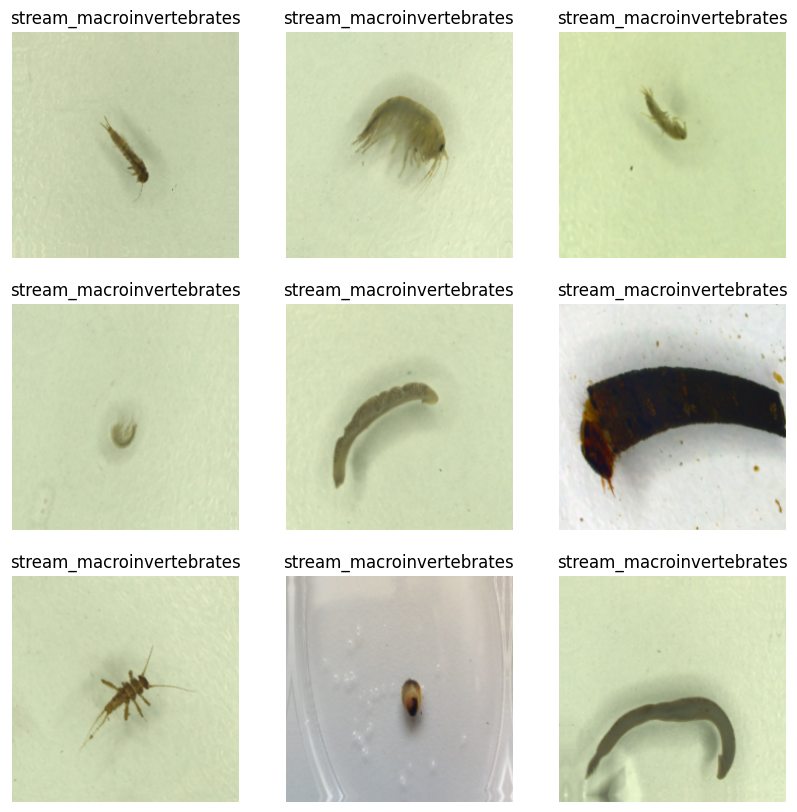

In [18]:
# === STEP 3: Data augmentation (recommended) ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

creates a training model to train from these images

In [19]:
# === STEP 4: Build transfer learning model ===

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze the base model initially

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

I think its self explanatory that its training the model but i have no idea what epoch is, unless its just what the model is called


In [20]:

# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


67/67 ━━━━━━━━━━━━━━━━━━━━ 26s 277ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 268ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s 322ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 267ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e

it created a graph about training curves but i don't see anything happening I wonder if i did anything wrong


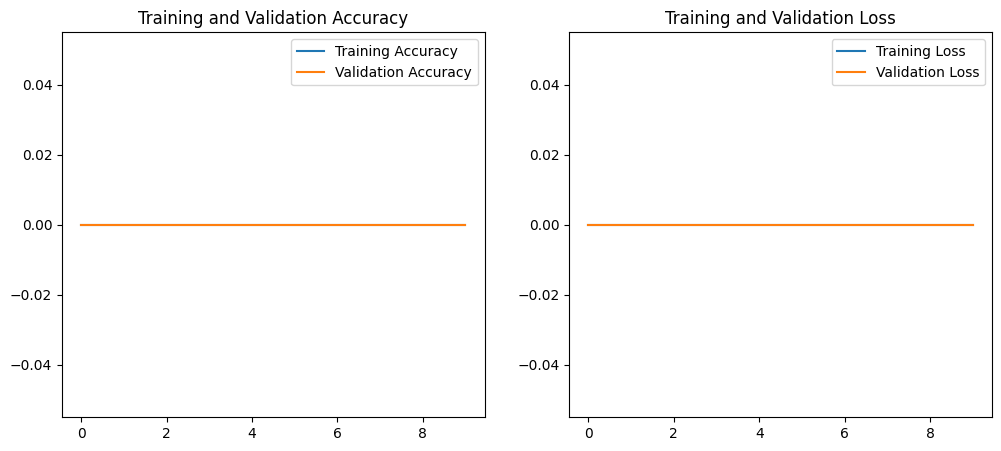

In [22]:
# === STEP 6: Plot training curves ===

# Re-extracting from history to ensure correct length for initial EPOCHS
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

yeah i think i did something wrong

In [23]:
# === STEP 7: Evaluate on validation set ===

val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Validation accuracy: 0.00%


Step 8 does not exist and step 9 says that the way of saving is considered legacy

In [25]:
# === STEP 9: Save the trained model ===
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities
model.save('macroinvertebrates_classifier.h5')
print("Model saved as 'macroinvertebrates_classifier.h5'")

/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities
Model saved as 'macroinvertebrates_classifier.h5'


still feels like something is wrong

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


<Figure size 1200x1200 with 0 Axes>

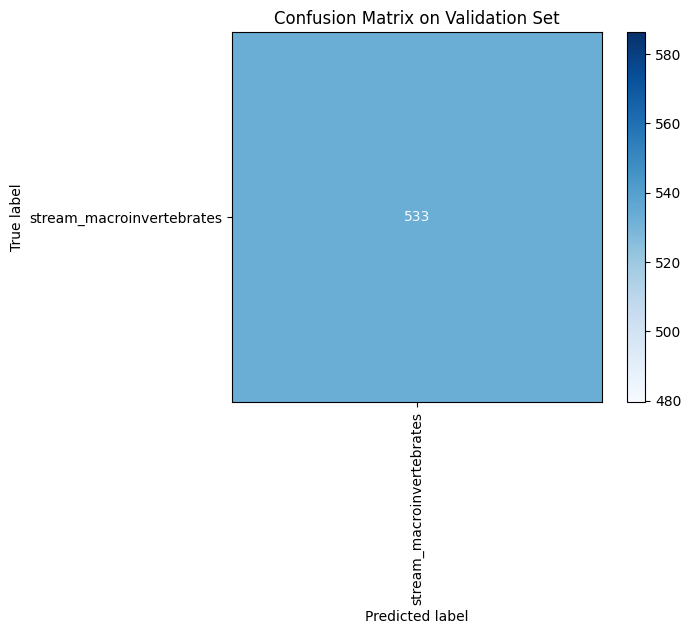

Weighted Precision: 1.0000
Weighted Recall:    1.0000
Weighted F1-score:  1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


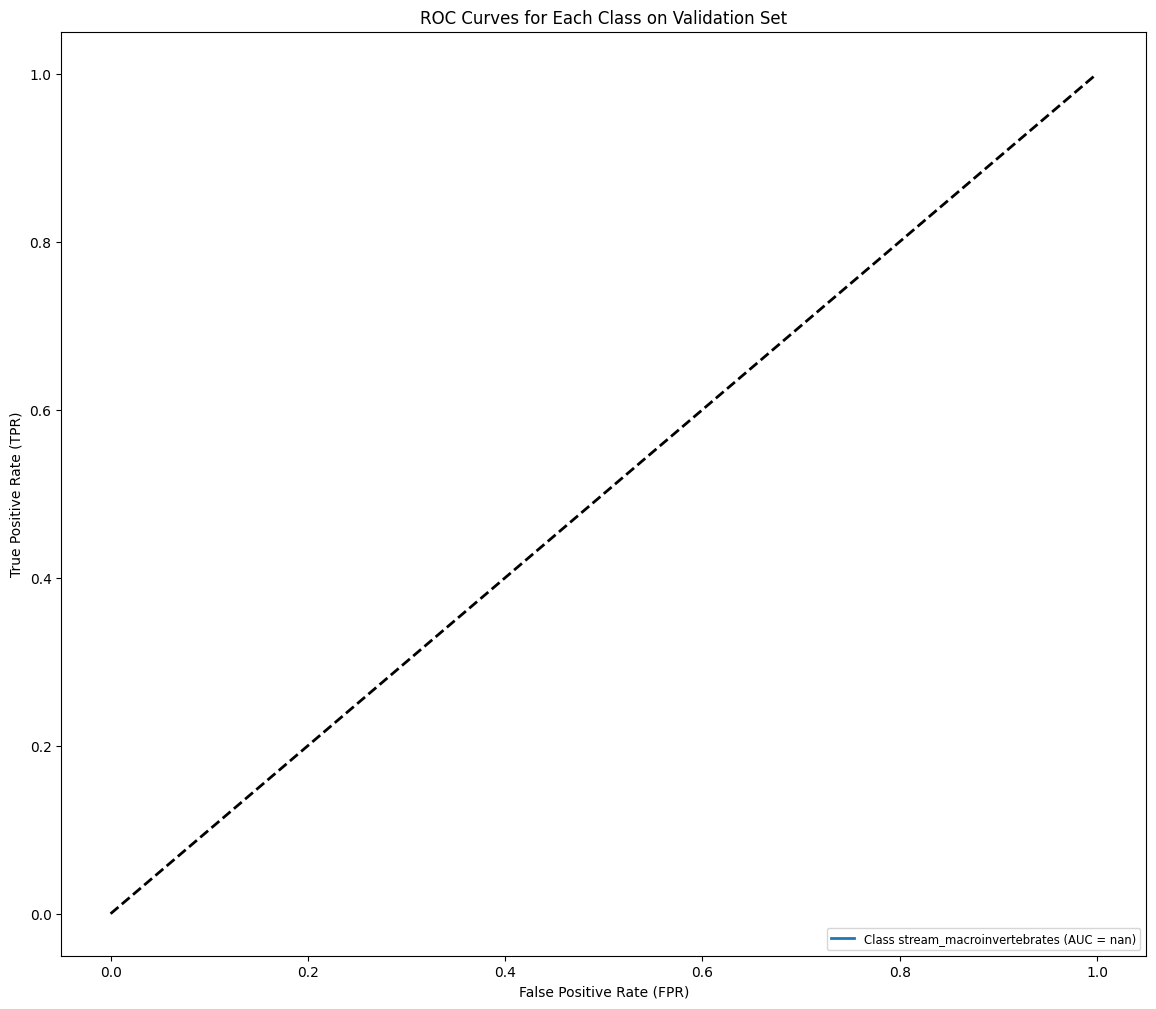

In [26]:
# === STEP 10: Evaluate model with confusion matrix, precision, recall, F1-score ===

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

# Step 10.1: Aggregate predictions and true labels from validation dataset
y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# Step 10.2: Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Step 10.3: Precision, Recall, F1-score (weighted average)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

# Step 10.4: Multi-class ROC curves and AUC

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()



In [28]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'. Please add some images and rerun.
